In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [14]:
df = pd.read_csv('spotify_tracks.csv')
df

,track_name,artist,genre,playlist_category,danceability,energy,valence,tempo,duration_ms,popularity
0,Love Sky,Artist_464,Classical,Chill,0.375,0.374,0.730,149.34,329908,89
1,Fire Dream,Artist_221,Bollywood,Romantic,0.951,0.333,0.185,124.30,339603,91
2,Light Night,Artist_357,Jazz,Sleep,0.732,0.176,0.347,195.03,130658,87
3,Love Wave Night,Artist_389,Pop,Workout,0.599,0.607,0.663,90.66,90342,71
4,Fire Light,Artist_451,EDM,Workout,0.156,0.477,0.482,142.30,233893,48
...,...,...,...,...,...,...,...,...,...,...
9995,Beat Sky Night,Artist_76,Classical,Travel,0.858,0.877,0.952,165.56,291349,87
9996,Sky Night Fire,Artist_230,Rock,Chill,0.898,0.047,0.748,167.03,111421,46
9997,Fire Beat,Artist_265,Pop,Party,0.947,0.304,0.019,97.74,303217,32
9998,Heart Love Dream,Artist_82,Jazz,Party,0.397,0.443,0.401,120.80,288904,1


In [15]:
# Data exploration
print(df.shape)
print(df.info())
print('\nMissing values:')
print(df.isnull().sum())

(10000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   track_name         10000 non-null  object 
 1   artist             10000 non-null  object 
 2   genre              10000 non-null  object 
 3   playlist_category  10000 non-null  object 
 4   danceability       10000 non-null  float64
 5   energy             10000 non-null  float64
 6   valence            10000 non-null  float64
 7   tempo              10000 non-null  float64
 8   duration_ms        10000 non-null  int64  
 9   popularity         10000 non-null  int64  
dtypes: float64(4), int64(2), object(4)
memory usage: 781.4+ KB
None

Missing values:
track_name           0
artist               0
genre                0
playlist_category    0
danceability         0
energy               0
valence              0
tempo                0
duration_ms          0
popularity 

In [16]:
# Statistical summary of numerical features
df.describe()

,danceability,energy,valence,tempo,duration_ms,popularity
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.494157,0.504532,0.500051,129.819853,210726.703300,50.235200
std,0.287634,0.289291,0.286779,40.459244,86588.246585,28.623141
min,0.000000,0.000000,0.000000,60.000000,60019.000000,1.000000
25%,0.246000,0.254000,0.254000,94.557500,135233.750000,25.000000
50%,0.493000,0.506000,0.502000,130.005000,209934.000000,50.000000
75%,0.740000,0.756000,0.745000,164.600000,286301.250000,75.000000
max,1.000000,1.000000,1.000000,199.970000,359994.000000,99.000000


In [17]:
# Select features for clustering
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select numeric features for clustering
features = ['danceability', 'energy', 'valence', 'tempo', 'duration_ms', 'popularity']
X = df[features]

# Standardize the features (important for K-means)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Features shape: {X_scaled.shape}")
print(f"Features used: {features}")

Features shape: (10000, 6)
Features used: ['danceability', 'energy', 'valence', 'tempo', 'duration_ms', 'popularity']


In [18]:
# Build K-means model with optimal clusters (let's use 5 clusters)
optimal_k = 5
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

print(f"K-means clustering completed with {optimal_k} clusters")
print(f"\nCluster distribution:")
print(df['cluster'].value_counts().sort_index())

K-means clustering completed with 5 clusters

Cluster distribution:
cluster
0    2018
1    1931
2    1956
3    2055
4    2040
Name: count, dtype: int64


<Figure size 1400x600 with 0 Axes>

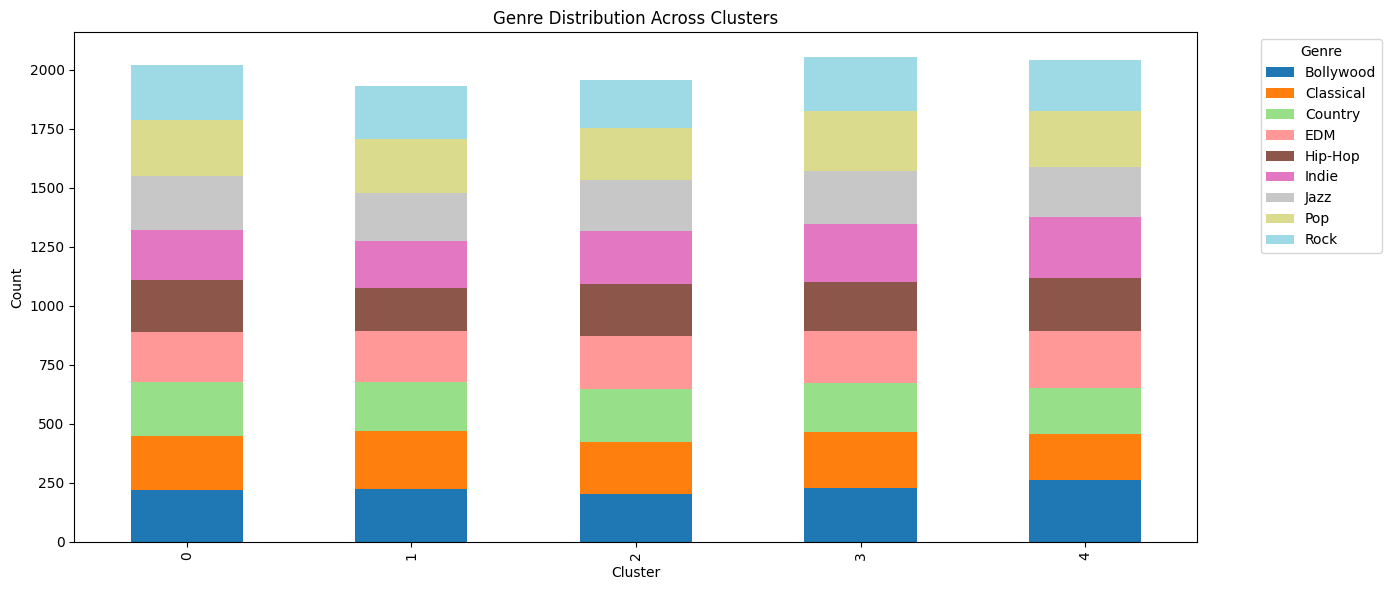

In [26]:
# Analyze genre distribution across clusters
plt.figure(figsize=(14, 6))
cluster_genre = pd.crosstab(df['cluster'], df['genre'])
cluster_genre.plot(kind='bar', stacked=True, figsize=(14, 6), colormap='tab20')
plt.xlabel('Cluster')
plt.ylabel('Count')
plt.title('Genre Distribution Across Clusters')
plt.legend(title='Genre', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [25]:
# Try with a specific song (change the song name as needed)
# Example: recommend_songs('Love Sky', n_recommendations=10)

song_input = 'Fire Beat'  # You can change this to any song in the dataset
recommendations = recommend_songs(song_input, n_recommendations=10)
recommendations


🎵 Recommendations for 'Fire Beat':
   Genre: Rock
   Cluster: 3



,track_name,artist,genre,playlist_category,popularity,distance
5239,Love Fire Dream,Artist_309,Indie,Sleep,81,59.734316
137,Dream Light,Artist_466,Country,Focus,21,194.859652
9261,Dream Fire Sky,Artist_298,Jazz,Workout,81,206.928550
2999,Beat Wave Night,Artist_277,Bollywood,Travel,15,215.154088
373,Wave Beat Light,Artist_334,Country,Chill,20,222.866676
9422,Dance Wave Beat,Artist_355,Country,Sleep,71,236.911135
508,Dream Dance,Artist_478,Rock,Chill,13,310.217804
5907,Light Heart,Artist_135,Rock,Romantic,57,313.596783
5303,Heart Wave,Artist_131,EDM,Focus,20,320.726023
276,Dance Dream,Artist_438,Jazz,Party,95,380.336425


In [24]:
# Example: Get recommendations for a random song
sample_song = df.sample(1)['track_name'].values[0]
print(f"Getting recommendations for: {sample_song}\n")
recommendations = recommend_songs(sample_song, n_recommendations=10)
recommendations

Getting recommendations for: Love Fire Dance


🎵 Recommendations for 'Love Fire Dance':
   Genre: Country
   Cluster: 4



,track_name,artist,genre,playlist_category,popularity,distance
2754,Beat Dance,Artist_311,Jazz,Party,9,115.737001
232,Light Dance Sky,Artist_385,EDM,Party,90,128.883093
2443,Love Fire,Artist_429,Pop,Focus,18,152.354360
4276,Sky Dance Dream,Artist_459,Hip-Hop,Party,56,179.526201
2691,Dance Night Beat,Artist_315,Pop,Focus,74,203.297049
1231,Dream Fire Beat,Artist_59,Pop,Romantic,65,267.675159
620,Wave Love Fire,Artist_258,Country,Travel,51,290.342671
1689,Dance Night Wave,Artist_227,Hip-Hop,Sleep,61,345.351475
4239,Dance Night Wave,Artist_128,Indie,Romantic,40,347.301464
5088,Heart Light Night,Artist_317,Rock,Workout,53,448.554137


In [23]:
# Song recommendation function
def recommend_songs(song_name, n_recommendations=10):
    """
    Recommend songs similar to the given song based on K-means clustering
    
    Parameters:
    - song_name: Name of the song to find recommendations for
    - n_recommendations: Number of recommendations to return
    
    Returns:
    - DataFrame with recommended songs
    """
    # Find the song in the dataset
    song_data = df[df['track_name'].str.lower() == song_name.lower()]
    
    if song_data.empty:
        print(f"Song '{song_name}' not found in the dataset.")
        return None
    
    # Get the cluster of the input song
    song_cluster = song_data['cluster'].values[0]
    
    # Get all songs from the same cluster
    cluster_songs = df[df['cluster'] == song_cluster]
    
    # Calculate similarity (Euclidean distance) to the input song
    song_features = song_data[features].values[0]
    
    # Calculate distances
    from scipy.spatial.distance import euclidean
    cluster_songs = cluster_songs.copy()
    cluster_songs['distance'] = cluster_songs[features].apply(
        lambda row: euclidean(row, song_features), axis=1
    )
    
    # Sort by distance and exclude the input song
    recommendations = cluster_songs[cluster_songs['track_name'] != song_data['track_name'].values[0]]
    recommendations = recommendations.sort_values('distance').head(n_recommendations)
    
    print(f"\n🎵 Recommendations for '{song_name}':")
    print(f"   Genre: {song_data['genre'].values[0]}")
    print(f"   Cluster: {song_cluster}")
    print(f"\n{'='*80}")
    
    return recommendations[['track_name', 'artist', 'genre', 'playlist_category', 'popularity', 'distance']]

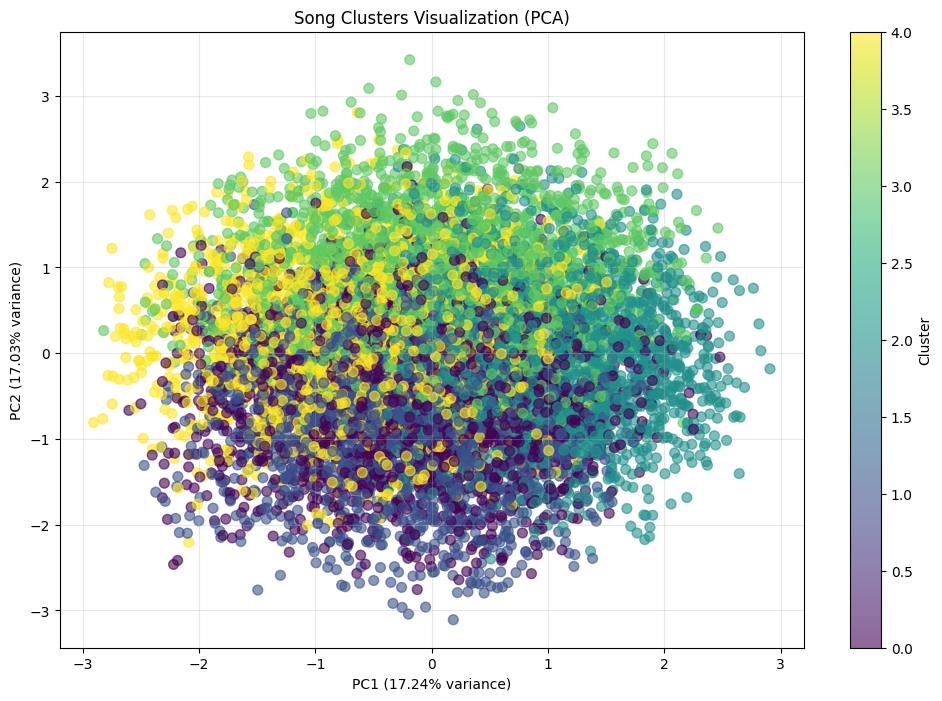

In [22]:
# Visualize clusters (using PCA for 2D visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(12, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df['cluster'], cmap='viridis', alpha=0.6, s=50)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('Song Clusters Visualization (PCA)')
plt.colorbar(scatter, label='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [21]:
# Analyze cluster characteristics
cluster_summary = df.groupby('cluster')[features].mean()
print("Cluster Characteristics (Mean values):")
print(cluster_summary.round(2))

Cluster Characteristics (Mean values):
         danceability  energy  valence   tempo  duration_ms  popularity
cluster                                                                
0                0.72    0.50     0.48   98.58    139887.73       52.66
1                0.35    0.51     0.79  107.99    258946.42       50.98
2                0.32    0.54     0.21  114.08    260681.66       50.34
3                0.74    0.49     0.49  163.75    264541.20       52.56
4                0.33    0.49     0.53  162.30    133050.28       44.69


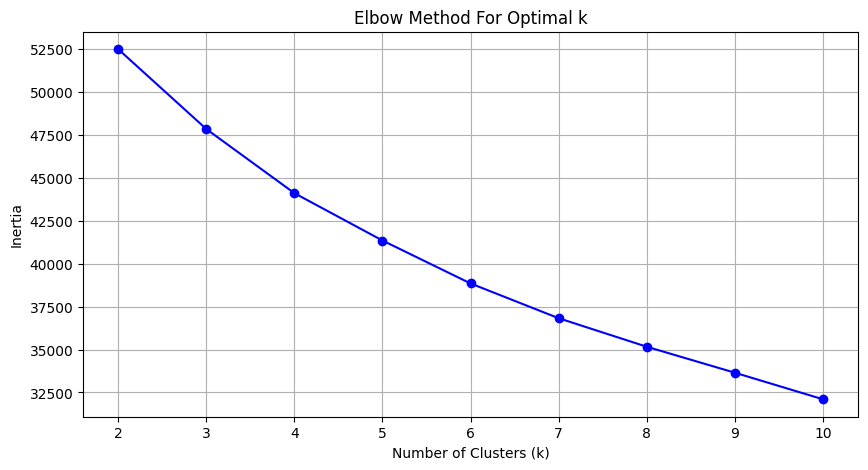

In [ ]:
# Elbow method to find optimal number of clusters
inertias = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(10, 5))
plt.plot(K_range, inertias, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()

For k=2, silhouette score = 0.1241
For k=3, silhouette score = 0.1119
For k=4, silhouette score = 0.1169
For k=5, silhouette score = 0.1186
For k=6, silhouette score = 0.1218
For k=7, silhouette score = 0.1245
For k=8, silhouette score = 0.1249
For k=9, silhouette score = 0.1280
For k=10, silhouette score = 0.1330


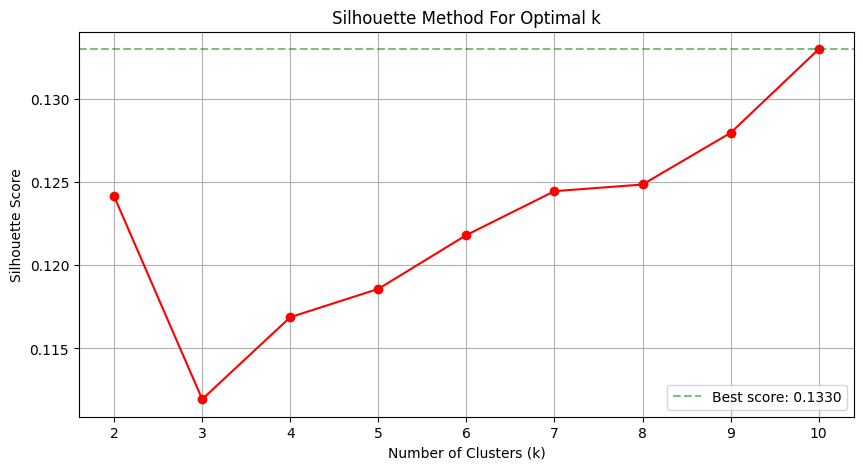


Optimal k based on Silhouette method: 10


In [27]:
# Silhouette method to find optimal number of clusters
from sklearn.metrics import silhouette_score

silhouette_scores = []
K_range = range(2, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)
    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    silhouette_scores.append(silhouette_avg)
    print(f"For k={k}, silhouette score = {silhouette_avg:.4f}")

# Plot the silhouette scores
plt.figure(figsize=(10, 5))
plt.plot(K_range, silhouette_scores, 'ro-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Method For Optimal k')
plt.grid(True)
plt.axhline(y=max(silhouette_scores), color='g', linestyle='--', alpha=0.5, label=f'Best score: {max(silhouette_scores):.4f}')
plt.legend()
plt.show()

# Find optimal k
optimal_k_silhouette = K_range[silhouette_scores.index(max(silhouette_scores))]
print(f"\nOptimal k based on Silhouette method: {optimal_k_silhouette}")